# Kalman Filter: acceleration as input

This extends the basic 1D Kalman filter by incorporating **acceleration information** (e.g., from an IMU).

We’ll simulate a moving object with time-varying acceleration, and we’ll assume we can measure:
- **position** (noisy)
- **acceleration** (noisy)

Then we’ll use the acceleration measurement as a **control input** in the prediction step.


## 1. Model overview (constant-velocity state + acceleration input)

The true system dynamics is exactly as defined in the previous notebook
`constant_velocity.ipynb`. 

That is, the state consists of position $x$, velocity $v$ and acceleration $a$.
The true dynamics of the point mass is assumed to be described by the state
equations (modeling accelerated motion)

$$
\begin{bmatrix} x_{k+1} \\ v_{k+1} \\ a_{k+1} \end{bmatrix} =  A \begin{bmatrix} x_k \\ v_k \\ a_k \end{bmatrix} + \mathsf{w}_k %B_k j_k
$$

with process noise $\mathsf{w}_k\sim\mathcal{N}(0,Q)$ where

$$
A = \begin{bmatrix} 1 & dt & \tfrac{1}{2}dt^2 \\ 0 & 1  & dt \\ 0 & 0  & 1 \end{bmatrix},\quad
Q = \sigma_j^2 \begin{bmatrix} \tfrac{dt^5}{20} & \tfrac{dt^4}{8} & \tfrac{dt^3}{6} \\ \tfrac{dt^4}{8}  & \tfrac{dt^3}{3} & \tfrac{dt^2}{2} \\ \tfrac{dt^3}{6}  & \tfrac{dt^2}{2} & dt \end{bmatrix}.
$$


In this case we assume position and **acceleration** (e.g. from IMU) measurements
$$
\begin{bmatrix} y^{(pos)}_k \\ y^{(acc)}_k \end{bmatrix} = H \begin{bmatrix} x_k \\ v_k \\ a_k \end{bmatrix} + \mathsf{v}_k,\quad 
$$
where $H=\begin{bmatrix}1 & 0 & 0 \\ 0 & 0 & 1\end{bmatrix}$ and $\mathsf{v}_k\sim\mathcal{N}(0,R), R=\begin{bmatrix}\sigma_{\mathsf{x}}^2 & \\ & \sigma_{\mathsf{a}}^2\end{bmatrix}$.

## 2. Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


def simulate_linear_model(n_steps: int,
                          dt: float,
                          p0: float,
                          v0: float,
                          a0: float,
                          sigma_j: float,
                          sigma_y_pos: float,
                          sigma_y_acc: float,
                          seed: int = 0):
    """
    Generate simulated motion of a point in 1D according to linear model
    
    Args:
        n_steps (int): number of steps to simulate.
        dt (float): time step.
        p0 (float): initial position.
        v0 (float): initial velocity.
        a0 (float): initial acceleration.
        sigma_j (float): standard deviation/intensity of jerk.
        sigma_y_pos (float): standard deviation of position measurement noise. If set <0, auto set to 0 ==> equal to true values
        sigma_y_acc (float): standard deviation of acceleration measurement noise. If set <0, auto set to 0 ==> equal to true values
        seed (int, optional): random seed for reproducibility. Defaults to 0.

    Returns:
        tuple: (true_pos, true_vel, y_pos, y_acc) arrays of positions, velocities, pos and acc measurements.
    
    Sensors:
        position measurement: y_pos = x + N(0, sigma_y_pos^2)
        acceleration measurement: y_acc = a + N(0, sigma_y_acc^2)
    """
    p = float(p0)
    v = float(v0)
    a = float(a0)

    A = np.array([
        [1.0, dt, 0.5*dt**2],
        [0.0, 1.0, dt],
        [0.0, 0.0, 1.0]
    ])

    H = np.array([
        [1, 0, 0],
        [0, 0, 1]
    ])

    sigma_j = np.max([0, sigma_j]).astype(float)
    sigma_y_pos = np.max([0, sigma_y_pos]).astype(float)
    sigma_y_acc = np.max([0, sigma_y_acc]).astype(float)

    Q = sigma_j**2 * np.array([
        [dt**5/20, dt**4/8,  dt**3/6],
        [dt**4/8,  dt**3/3,  dt**2/2],
        [dt**3/6,  dt**2/2,  dt]
    ])

    R = np.diag([sigma_y_pos**2, sigma_y_acc**2])

    pos, vel, acc = [], [], []
    y_pos, y_acc = [], []
    x = np.array([p, v, a]).reshape(3, 1)

    for k in range(n_steps):
        # acceleration
        rng = np.random.default_rng(seed + k)

        # sample noise
        w = rng.multivariate_normal(np.zeros(3), Q).reshape(3,1)

        # interate/integrate
        x = A @ x + w

        # extract
        p = x[0,0]
        v = x[1,0]
        a = x[2,0]

        # append history
        pos.append(p)
        vel.append(v)
        acc.append(a)

        # noisy pos + acc measurements
        v = rng.multivariate_normal(np.zeros(2), R).reshape(2,1)
        y = H @ x + v
        y_pos.append(y[0, 0])
        y_acc.append(y[1, 0])

    return (np.array(pos), np.array(vel), np.array(acc),
            np.array(y_pos), np.array(y_acc))

## 3. Kalman filter using acceleration as control input

The filter now exploits acceleration measurements which are handled as driving input in the state equations of the filter:

- We use the measured acceleration $y^{(acc)}_k$ as input.
- Its noise $\mathsf{v}^a_k\sim\mathcal{N}(0,\sigma_{\mathsf{a}}^2)$ contributes to the prediction covariance via:
$
Q = \sigma_{\mathsf{a}}^2\,(B B^T), \quad B=\begin{bmatrix}\tfrac{dt^2}{2} \\ dt \end{bmatrix}.
$

This is like having a filter based on the following state equations:

$$
\begin{bmatrix} x_{k+1} \\ v_{k+1} \end{bmatrix} =  A \begin{bmatrix} x_k \\ v_k \end{bmatrix} + By^{(acc)}_k, \quad y^{(acc)}_k\sim\mathcal{N}(a_k,\sigma_{\mathsf{a}}^2)
$$

where 

$$
A = \begin{bmatrix} 1 & dt \\ 0 & 1 \end{bmatrix}, \quad
B=\begin{bmatrix}\tfrac{dt^2}{2} \\ dt \end{bmatrix}, \quad
Q = \sigma_a^2BB^T = \sigma_a^2\begin{bmatrix}\tfrac{dt^4}{4} & \tfrac{dt^3}{2} \\ \tfrac{dt^3}{2} & dt^2 \end{bmatrix}
$$

assuming process noise is due to the acceleration measurement noise "projected" through the input matrix.

**NOTE:** to be precise the process covariance matrix $Q$ should consist of a
*model mismatch* part plus the noise contribute. Here we simplify and
consider only the noise contribute.

The position measurement model is similar to the one previously defined, i.e.

$$
y^{(pos)}_k = H \begin{bmatrix} x_k \\ v_k \end{bmatrix} + \mathsf{v}_k,\quad 
$$

where $H=\begin{bmatrix}1 & 0 \end{bmatrix}$ and $\mathsf{v}_k\sim\mathcal{N}(0,R), R=\sigma_{\mathsf{v}}^2$.

In [2]:
def kalman_filter_constant_velocity_with_acceleration(y_pos: np.ndarray,
                                                      y_acc: np.ndarray,
                                                      dt: float,
                                                      x0: np.ndarray,
                                                      P0: np.ndarray,
                                                      sigma_y_pos: float,
                                                      sigma_y_acc: float):
    """
    Implement KF equations moving point in 1D assuming a constant velocity model.
    with acceleration measurement used as control input.

    Args:
        y_pos (np.ndarray): array of noisy position measurements.
        y_acc (np.ndarray): array of noisy acceleration meansurements
        dt (float): time step.
        x0 (np.ndarray): initial state [position, velocity].
        P0 (np.ndarray): initial covariance matrix.
        sigma_y_pos (float): standard deviation of position measurement noise.
        sigma_y_acc (float): standard deviation of acceleration measurement noise.

    Returns:
        np.ndarray: array of estimated states [position, velocity] at each time step.
        List[np.ndarray]: list of covariance error matrix at each time step.
    """
    A = np.array([[1.0, dt], [0.0, 1.0]])
    B = np.array([[0.5 * dt**2], [dt]])  # explicitly used in the filter equations
    H = np.array([[1.0, 0.0]])
    R = np.array([[sigma_y_pos**2]])

    # Process noise induced by accel noise
    Q = (sigma_y_acc**2) * (B @ B.T)

    I = np.eye(2)
    x = x0.reshape(2, 1)
    P = P0.copy()

    xs = []
    Ps = []

    for yk_pos, uk_acc in zip(y_pos, y_acc):
        # Measurements
        yk = np.array([[yk_pos]])
        u = np.array([[uk_acc]])

        # Predict
        x_pred = A @ x + B @ u  # the novelty is how B and u are used
        P_pred = A @ P @ A.T + Q

        # Update (position)
        e = yk - (H @ x_pred)
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x = x_pred + K @ e
        P = (I - K @ H) @ P_pred

        xs.append(x.flatten())
        Ps.append(P.copy())

    return np.array(xs), np.array(Ps)


## 5. Run simulation + filter

In [3]:
# Time settings
dt = 0.1
n_steps = 200
p0 = 0
v0 = 0
a0 = 0

# True system behavior: random acceleration values
sigma_j_true = 0.8

# Sensor noise
sigma_y_pos_true = 2.0   # position sensor std
sigma_y_acc_true = 0.8   # accelerometer std

# generate true motion and measurements
true_pos, true_vel, true_acc, y_pos, y_acc = simulate_linear_model(
    n_steps, dt,
    p0, v0, a0,
    sigma_j_true, sigma_y_pos_true, sigma_y_acc_true,
    seed=42)

# defined the filter noise parameters
# Currently equal to the true ones -> This is the best we can do!!!
sigma_y_pos_filter = 2.0
sigma_y_acc_filter = 0.8

# Initial belief
x0 = np.array([0.0, 0.0])
P0 = np.diag([10.0**2, 10.0**2])

# run the filter
xs, Ps = kalman_filter_constant_velocity_with_acceleration(
    y_pos, y_acc, dt, x0, P0, sigma_y_pos_filter, sigma_y_acc_filter
)

# extract estimates
est_pos = xs[:, 0]
est_vel = xs[:, 1]
t = np.arange(n_steps) * dt  # time vector for plotting
sigma_pos = np.sqrt(Ps[:, 0, 0])
sigma_vel = np.sqrt(Ps[:, 1, 1])

# some MSE computations
mse_pos = np.mean((true_pos - est_pos)**2)
mse_vel = np.mean((true_vel - est_vel)**2)

print(f"Position MSE: {mse_pos:.4f}")
print(f"Velocity MSE: {mse_vel:.4f}")


Position MSE: 0.5044
Velocity MSE: 0.5621


## 6. Plot: acceleration (truth vs measurement)

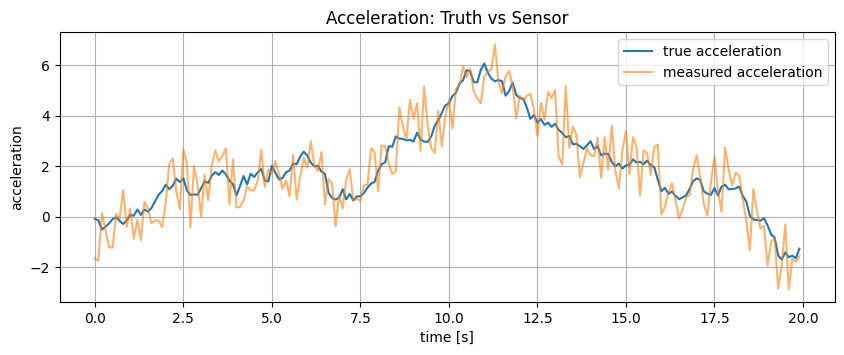

In [4]:
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_acc, label='true acceleration')
plt.plot(t, y_acc, alpha=0.6, label='measured acceleration')
plt.xlabel('time [s]')
plt.ylabel('acceleration')
plt.title('Acceleration: Truth vs Sensor')
plt.grid(True)
plt.legend()
plt.show()

## 7. Resuts: Position and Velocity - True vs Estimated

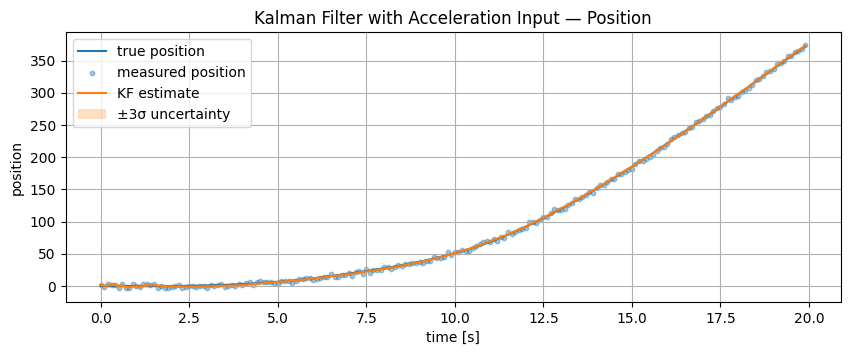

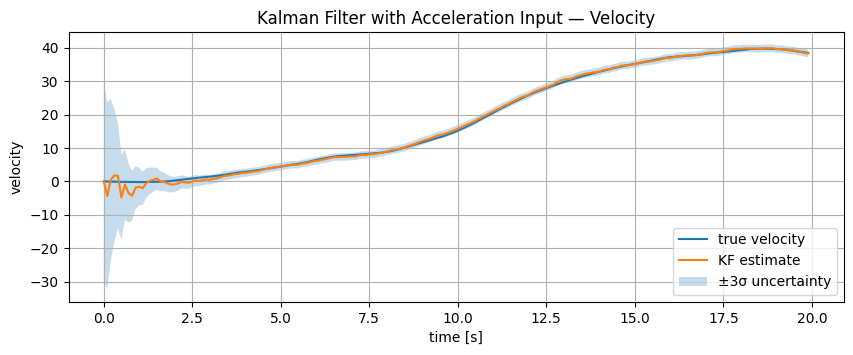

In [5]:
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_pos, label='true position')
plt.scatter(t, y_pos, s=10, alpha=0.4, label='measured position')
plt.plot(t, est_pos, label='KF estimate')
plt.fill_between(t, est_pos - 3*sigma_pos, est_pos + 3*sigma_pos, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('position')
plt.title('Kalman Filter with Acceleration Input — Position')
plt.grid(True)
plt.legend()
plt.show()

# plot the velocity
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_vel, label='true velocity')
plt.plot(t, est_vel, label='KF estimate')
plt.fill_between(t, est_vel - 3*sigma_vel, est_vel + 3*sigma_vel, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('velocity')
plt.title('Kalman Filter with Acceleration Input — Velocity')
plt.grid(True)
plt.legend()
plt.show()